In [2]:
from google.colab import drive
import tensorflow as tf
import os


drive.mount('/content/drive')
gpu_durumu = tf.config.list_physical_devices('GPU')
if gpu_durumu:
    print("T4 GPU devrede")
else:
    print("T4 GPU devre disi")

Mounted at /content/drive
T4 GPU devrede


In [3]:
import tensorflow as tf

base_dir = '/content/drive/MyDrive/Tez_Verileri/COVID-19_Radiography_Dataset'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='rgb',
    label_mode='categorical'
)

class_names = train_dataset.class_names
print("\n" + "="*50)
print(f"SİSTEME YÜKLENEN HASTALIK SINIFLARI:")
for i, name in enumerate(class_names):
    print(f"{i+1}. {name}")
print("="*50)

Found 42330 files belonging to 4 classes.
Using 33864 files for training.
Found 42330 files belonging to 4 classes.
Using 8466 files for validation.

SİSTEME YÜKLENEN HASTALIK SINIFLARI:
1. COVID
2. Lung_Opacity
3. Normal
4. Viral Pneumonia


In [4]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

print("ResNet50V2 indiriliyor")

base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)

predictions = Dense(4, activation='softmax')(x)

model_v2 = Model(inputs=base_model.input, outputs=predictions)

model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("\nV2.0 Çoklu Hastalık Teşhis Modeli başarıyla kuruldu")
model_v2.summary()

ResNet50V2 indiriliyor
94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

V2.0 Çoklu Hastalık Teşhis Modeli başarıyla kuruldu


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,572,996 (89.92 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [5]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

korumalar = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('tez_v2_en_iyi_model.h5', monitor='val_accuracy', save_best_only=True)
]

history_v2 = model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=korumalar
)

print("\nEĞİTİM BAŞARIYLA TAMAMLANDI")

Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4295 - loss: 34.8426

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 5908s 6s/step - accuracy: 0.4656 - loss: 17.4228 - val_accuracy: 0.6132 - val_loss: 3.7868
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 179s 169ms/step - accuracy: 0.5003 - loss: 7.2936 - val_accuracy: 0.5032 - val_loss: 9.4711
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 178s 168ms/step - accuracy: 0.5127 - loss: 6.9037 - val_accuracy: 0.3135 - val_loss: 13.1056
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 182s 172ms/step - accuracy: 0.5178 - loss: 6.7418 - val_accuracy: 0.4435 - val_loss: 6.4346

EĞİTİM BAŞARIYLA TAMAMLANDI


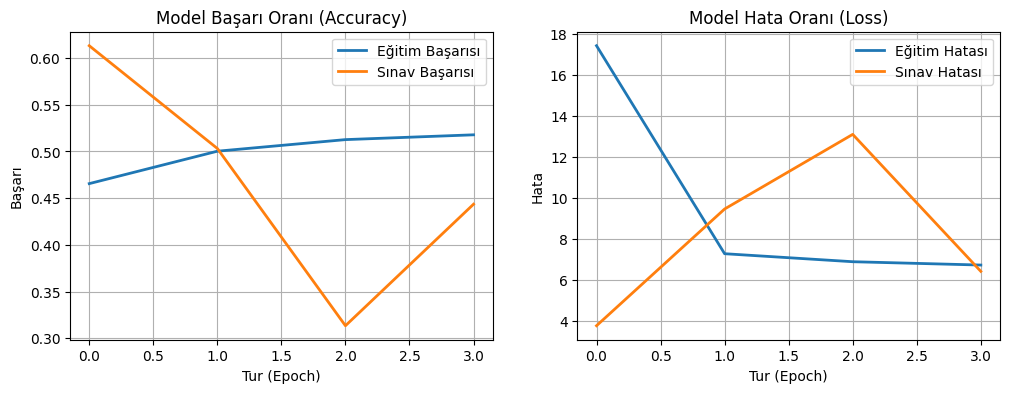

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_v2.history['accuracy'], label='Eğitim Başarısı', linewidth=2)
plt.plot(history_v2.history['val_accuracy'], label='Sınav Başarısı', linewidth=2)
plt.title('Model Başarı Oranı (Accuracy)')
plt.ylabel('Başarı')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_v2.history['loss'], label='Eğitim Hatası', linewidth=2)
plt.plot(history_v2.history['val_loss'], label='Sınav Hatası', linewidth=2)
plt.title('Model Hata Oranı (Loss)')
plt.ylabel('Hata')
plt.xlabel('Tur (Epoch)')
plt.legend()
plt.grid(True)

plt.show()

In [7]:


base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

print("katman sayısı: 50")


model_v2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("\n2. AŞAMA EĞİTİMİ")


korumalar_finetune = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('tez_v2_finetune_en_iyi.h5', monitor='val_accuracy', save_best_only=True)
]


history_finetune = model_v2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=korumalar_finetune
)

print("\nTAMAMLANDI")

katman sayısı: 50

2. AŞAMA EĞİTİMİ
Epoch 1/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.5461 - loss: 1.2511

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 233s 198ms/step - accuracy: 0.6338 - loss: 0.9098 - val_accuracy: 0.7563 - val_loss: 0.6168
Epoch 2/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.7389 - loss: 0.6505

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 188s 177ms/step - accuracy: 0.7507 - loss: 0.6185 - val_accuracy: 0.7790 - val_loss: 0.5627
Epoch 3/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7854 - loss: 0.5434

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 187s 177ms/step - accuracy: 0.7954 - loss: 0.5224 - val_accuracy: 0.7934 - val_loss: 0.5258
Epoch 4/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.8194 - loss: 0.4672

1059/1059 ━━━━━━━━━━━━━━━━━━━━ 187s 176ms/step - accuracy: 0.8259 - loss: 0.4502 - val_accuracy: 0.8056 - val_loss: 0.5002
Epoch 5/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 186s 175ms/step - accuracy: 0.8527 - loss: 0.3817 - val_accuracy: 0.7954 - val_loss: 0.5261
Epoch 6/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 183s 173ms/step - accuracy: 0.8774 - loss: 0.3215 - val_accuracy: 0.7941 - val_loss: 0.5635
Epoch 7/10
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 191s 180ms/step - accuracy: 0.9042 - loss: 0.2572 - val_accuracy: 0.7967 - val_loss: 0.6030

TAMAMLANDI


Tahminler toplanıyor

SINAV BİTTİ 

  SINIFLANDIRMA RAPORU 
                 precision    recall  f1-score   support

          COVID       0.73      0.64      0.68      1470
   Lung_Opacity       0.77      0.77      0.77      2449
         Normal       0.84      0.87      0.86      4048
Viral Pneumonia       0.88      0.91      0.90       499

       accuracy                           0.81      8466
      macro avg       0.81      0.80      0.80      8466
   weighted avg       0.80      0.81      0.80      8466



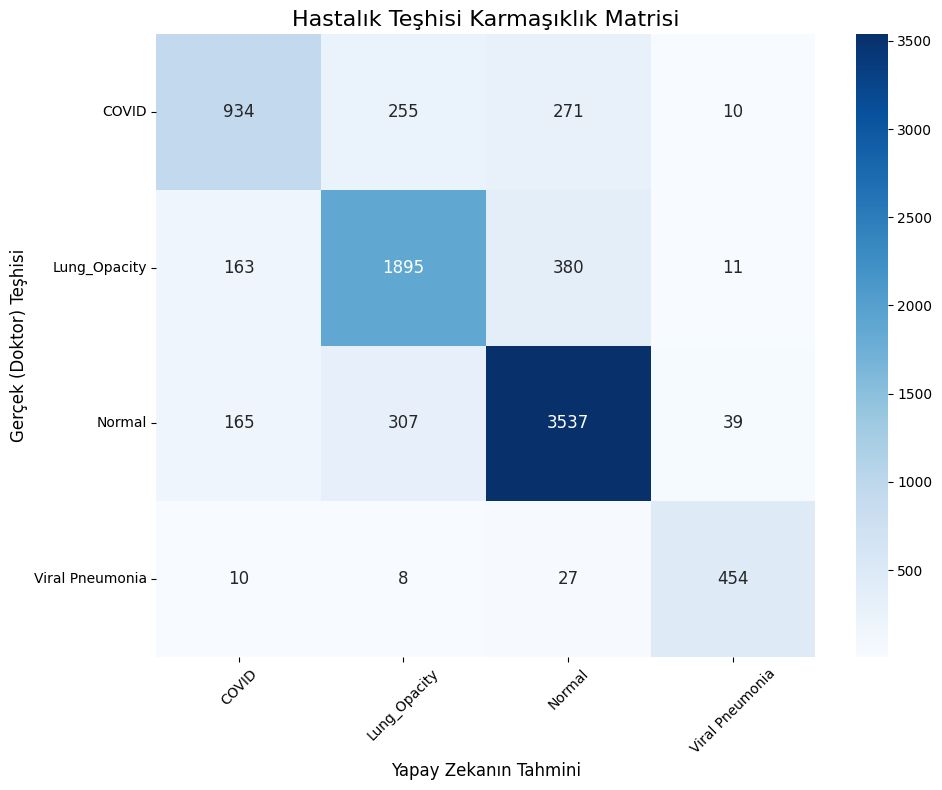

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Tahminler toplanıyor")


y_gercek = []
y_tahmin = []


for images, labels in val_dataset:

    y_gercek.extend(np.argmax(labels.numpy(), axis=1))


    tahmin_ihtimalleri = model_v2.predict(images, verbose=0)
    y_tahmin.extend(np.argmax(tahmin_ihtimalleri, axis=1))

y_gercek = np.array(y_gercek)
y_tahmin = np.array(y_tahmin)

print("\nSINAV BİTTİ \n")
print("="*60)
print("  SINIFLANDIRMA RAPORU ")
print("="*60)

print(classification_report(y_gercek, y_tahmin, target_names=class_names))


cm = confusion_matrix(y_gercek, y_tahmin)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 12})
plt.title('Hastalık Teşhisi Karmaşıklık Matrisi', fontsize=16)
plt.ylabel('Gerçek (Doktor) Teşhisi', fontsize=12)
plt.xlabel('Yapay Zekanın Tahmini', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

CANLI TEŞHİS SİSTEMİ AKTİF
Lütfen bilgisayarınızdan bir röntgen (X-Ray) fotoğrafı seçin...



Saving covid.webp to covid (1).webp

 Fotoğraf yüklendi: covid (1).webp
 Yapay Zeka analiz ediyor, lütfen bekleyin...


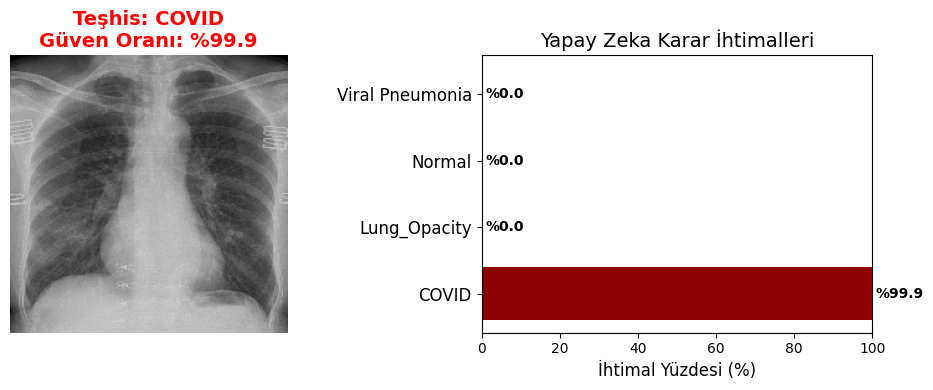


 Analiz Tamamlandı


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image

print("CANLI TEŞHİS SİSTEMİ AKTİF")
print("Lütfen bilgisayarınızdan bir röntgen (X-Ray) fotoğrafı seçin...\n")


uploaded = files.upload()


for fn in uploaded.keys():
    print(f"\n Fotoğraf yüklendi: {fn}")
    print(" Yapay Zeka analiz ediyor, lütfen bekleyin...")


    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)


    tahmin_ihtimalleri = model_v2.predict(img_array, verbose=0)[0]


    kazanan_index = np.argmax(tahmin_ihtimalleri)
    kesin_teşhis = class_names[kazanan_index]
    guven_orani = tahmin_ihtimalleri[kazanan_index] * 100


    plt.figure(figsize=(10, 4))


    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Teşhis: {kesin_teşhis}\nGüven Oranı: %{guven_orani:.1f}", color='red' if kesin_teşhis != 'Normal' else 'green', fontsize=14, fontweight='bold')


    plt.subplot(1, 2, 2)

    renkler = ['green' if name == 'Normal' else 'darkred' for name in class_names]
    y_pos = np.arange(len(class_names))
    plt.barh(y_pos, tahmin_ihtimalleri * 100, color=renkler)
    plt.yticks(y_pos, class_names, fontsize=12)
    plt.xlabel('İhtimal Yüzdesi (%)', fontsize=12)
    plt.title('Yapay Zeka Karar İhtimalleri', fontsize=14)
    plt.xlim(0, 100)


    for i, v in enumerate(tahmin_ihtimalleri * 100):
        plt.text(v + 1, i, f"%{v:.1f}", color='black', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n Analiz Tamamlandı")